# Env setup

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

import matplotlib.pyplot as plt
from arch.univariate import HARX#, Constant, Normal

In [9]:
def simulate_rv_series(n_days=1000, seed=42):
    np.random.seed(seed)
    
    # Parameters for the Log-RV process
    # Financial RV is highly persistent (phi close to 1)
    phi = 0.95 
    mu = -9.0    # Long-run mean of log-volatility
    sigma_v = 0.2 # Volatility of volatility (vov)
    
    log_rv = np.zeros(n_days)
    log_rv[0] = mu
    
    # Generate the AR(1) process in log-space
    for t in range(1, n_days):
        # We add some occasional "jumps" (heavy tails) using a t-distribution 
        # or Bernoulli-Gaussian to make Median Regression relevant
        jump = 2.0 if np.random.rand() > 0.98 else 0.0
        
        log_rv[t] = mu + phi * (log_rv[t-1] - mu) + np.random.normal(0, sigma_v) + jump

    # Convert back to levels (Exponential)
    rv_series = np.exp(log_rv)
    
    # Create a time index (Business days)
    dates = pd.date_range(start='2020-01-01', periods=n_days, freq='B')
    return pd.Series(rv_series, index=dates, name='Realized_Volatility')

In [40]:
def simulate_contaminated_har(n_days=1500):
    np.random.seed(44)

    beta = [-0.9, 0.45, 0.30, 0.15] 
    
    log_rv = np.zeros(n_days)
    log_rv[:22] = -9.0 
    
    for t in range(22, n_days):

        rv_d = log_rv[t-1]
        rv_w = np.mean(log_rv[t-5:t])
        rv_m = np.mean(log_rv[t-22:t])
        
        innovation = np.random.normal(0, 0.2)

        # Rare large positive shocks (volatility spikes)
        if np.random.rand() > 0.99:
            innovation += np.random.exponential(4)

        log_rv[t] = (
            beta[0]
            + beta[1]*rv_d
            + beta[2]*rv_w
            + beta[3]*rv_m
            + innovation
        )

    return pd.Series(np.exp(log_rv), name='RV')


In [46]:
def prepare_har_data(rv_series):
    df = pd.DataFrame({'RV_d': rv_series})
    # Create the weekly (5-day) and monthly (22-day) averages
    df['RV_w'] = df['RV_d'].rolling(window=5).mean()
    df['RV_m'] = df['RV_d'].rolling(window=22).mean()
    
    # Target is the next day's RV
    df['Target'] = df['RV_d'].shift(-1)
    return df.dropna()

# Realized Volatility (RV) forecasting models
(see Horta & Ziegelmann, 2018)

## Benchmark HAR Strategies <br>

### Strategy Ben1
This strategy assumes that the conditional variance satisfies a logarithmic version of the Heterogeneous Autoregressive model of Realized Volatility (HAR-RV). The model incorporates components representing daily, weekly, and monthly volatility horizons:
\begin{equation}
    \log\left(\varsigma_t^2\right) = a_0 + a_1 \log\left(\varsigma_{t-1}^2\right) + a_2 \log\left(\varsigma_{t-1, \text{w}}^2\right) + a_3 \log\left(\varsigma_{t-1, \text{m}}^2\right) + \varepsilon_t,
\end{equation}
where the weekly and monthly components are defined as the moving averages:
\begin{equation}
    \varsigma_{t, \text{w}}^2 = \frac{1}{5} \sum_{i=0}^{4} \varsigma_{t-i}^2, \quad \text{and} \quad \varsigma_{t, \text{m}}^2 = \frac{1}{22} \sum_{i=0}^{21} \varsigma_{t-i}^2.
\end{equation}
The parameter estimates $\widehat{a}_{j|n}$ are obtained through a robust median regression fit. The one-step-ahead forecast is given by:
\begin{equation}
    \widehat{\varsigma}^2_{n+1|n, \text{Ben1}} := \exp \left\{ \widehat{a}_{0|n} + \widehat{a}_{1|n} \log(\widehat{\varsigma}_n^2) + \widehat{a}_{2|n} \log(\widehat{\varsigma}_{n, \text{w}}^2) + \widehat{a}_{3|n} \log(\widehat{\varsigma}_{n, \text{m}}^2) \right\}.
\end{equation}

In [ ]:
# R code
# # Install and load the package
# install.packages("highfrequency")
# library(highfrequency)

# # Assume 'rv_data' is an xts object of daily realized variance
# # Fit a standard HAR-RV model
# har_fit <- harModel(data = rv_data, periods = c(1, 5, 22), type = "HAR")

# # View summary statistics
# summary(har_fit)

# # Generate a one-step-ahead forecast
# predict(har_fit)

# # Plot the fitted vs actual values
# plot(har_fit)

# 2. Implementation with Extensions (Jumps & Leverage)

# Since you mentioned Ben2 (including jumps and leverage) in your Notion notes, the highfrequency package supports these variants directly:

# HAR-J (Jumps): Set type = "HARJ" to include jump components.

# HAR-CJ (Continuous/Jump): Set type = "HARCJ" to decompose volatility into continuous and jump parts.

# L-HAR (Leverage): Use the leverage parameter to account for asymmetric responses to negative returns.

###### With median regression (less sensible to outliers compared to OLS)
# library(quantreg)
# library(zoo)

# # Create weekly and monthly moving averages
# rv_d <- lag(rv_data, -1)
# rv_w <- rollmean(rv_data, k = 5, align = "right", fill = NA)
# rv_m <- rollmean(rv_data, k = 22, align = "right", fill = NA)

# # Combine into a dataframe for modeling
# har_df <- data.frame(RV = rv_data, RV_d = rv_d, RV_w = rv_w, RV_m = rv_m)

# # Robust Median Regression (as in your Ben1 strategy)
# ben1_model <- rq(log(RV) ~ log(RV_d) + log(RV_w) + log(RV_m), data = har_df, tau = 0.5)

In [41]:
# Generate data
rv_series = simulate_rv_series()
rv_contaminated_series = simulate_contaminated_har()

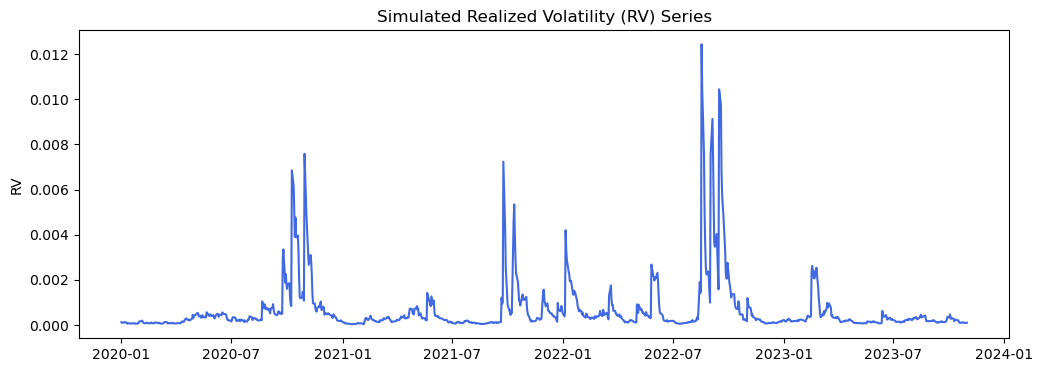

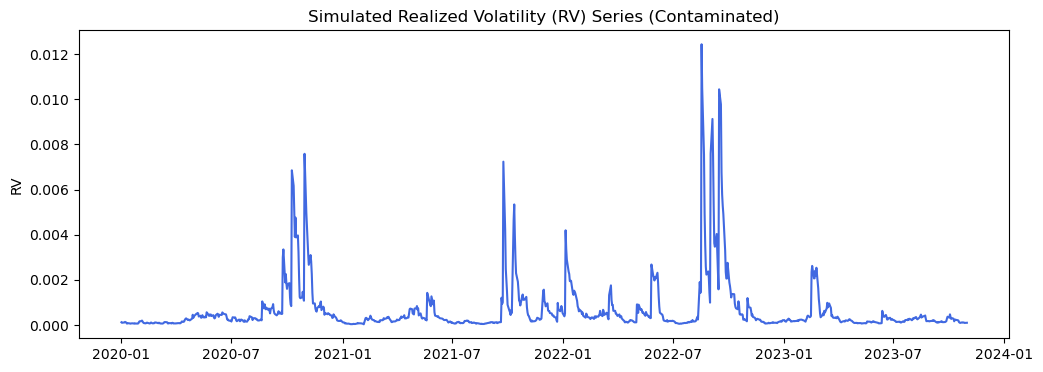

In [43]:
plt.figure(figsize=(12, 4))
plt.plot(rv_series, color='royalblue')
plt.title("Simulated Realized Volatility (RV) Series")
plt.ylabel("RV")
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(rv_series, color='royalblue')
plt.title("Simulated Realized Volatility (RV) Series (Contaminated)")
plt.ylabel("RV")
plt.show()
# Generate the data
rv_series = simulate_rv_series()

In [44]:
# Assume rv_series is a pandas Series of daily realized variance
# Note: lags=[1, 5, 22] is the standard HAR specification
har_model = HARX(rv_series, lags=[1, 5, 22])
res = har_model.fit()

print(res.summary())
forecasts = res.forecast(horizon=1)

                     HAR - Constant Variance Model Results                     
Dep. Variable:     Realized_Volatility   R-squared:                       0.689
Mean Model:                        HAR   Adj. R-squared:                  0.688
Vol Model:           Constant Variance   Log-Likelihood:                5731.27
Distribution:                   Normal   AIC:                          -11452.5
Method:             Maximum Likelihood   BIC:                          -11428.1
                                         No. Observations:                  978
Date:                 Sun, Mar 15 2026   Df Residuals:                      974
Time:                         21:15:16   Df Model:                            4
                                    Mean Model                                    
                       coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------------
Const            6.5270e-05  2.

/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 4.758e-07. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 1000 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [45]:
har_model = HARX(rv_contaminated_series, lags=[1, 5, 22])
res = har_model.fit()

print(res.summary())
forecasts = res.forecast(horizon=1)

                    HAR - Constant Variance Model Results                     
Dep. Variable:                     RV   R-squared:                       0.000
Mean Model:                       HAR   Adj. R-squared:                 -0.002
Vol Model:          Constant Variance   Log-Likelihood:               -20011.4
Distribution:                  Normal   AIC:                           40032.9
Method:            Maximum Likelihood   BIC:                           40059.4
                                        No. Observations:                 1478
Date:                Sun, Mar 15 2026   Df Residuals:                     1474
Time:                        21:15:16   Df Model:                            4
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
Const       4849.9625   4848.294      1.000      0.317 

/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 3.372e+10. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.0001 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [47]:
# 1. Prepare data
har_df = prepare_har_data(rv_series)
har_df

,RV_d,RV_w,RV_m,Target
2020-01-30,0.000131,0.000081,0.000088,0.000166
2020-01-31,0.000166,0.000100,0.000090,0.000171
2020-02-03,0.000171,0.000121,0.000093,0.000200
2020-02-04,0.000200,0.000148,0.000098,0.000160
2020-02-05,0.000160,0.000166,0.000100,0.000115
...,...,...,...,...
2023-10-24,0.000106,0.000111,0.000225,0.000115
2023-10-25,0.000115,0.000108,0.000225,0.000112
2023-10-26,0.000112,0.000109,0.000223,0.000094
2023-10-27,0.000094,0.000109,0.000219,0.000101


In [ ]:
# 2. Fit Log-HAR with Median Regression (Strategy Ben1)
# Notion formula: log(RV) ~ a0 + a1*log(RV_d) + a2*log(RV_w) + a3*log(RV_m)
model = smf.quantreg('np.log(Target) ~ np.log(RV_d) + np.log(RV_w) + np.log(RV_m)', har_df)
res = model.fit(q=0.5) # q=0.5 is the Median (Robust)

print(res.summary())


### Strategy Ben2
Strategy Ben2 generalizes the Ben1 model by including additional components to capture "jumps" and "leverage" effects. This follows the specifications proposed by \cite{CorsiReno2012}, allowing the model to account for the asymmetric response of volatility to negative returns and the presence of discontinuous price movements.

## Direct Density Forecast Strategies
The first class of strategies utilizes the functional time series framework to derive volatility estimates from the properties of the forecasted density.

### Strategies Fcst1V and Fcst1H
Based on the density forecasts obtained via functional principal component analysis (FPCA) and Vector Autoregression (VAR), we define the one-step-ahead conditional variance estimate as:
\begin{equation}
    \widehat{\varsigma}^2_{n+1|n, \text{Fcst1}} := n_{n+1} \times \text{Var}\left( \widehat{f}_{n+1|n} \right),
\end{equation}
where $n_{n+1}$ represents a scaling factor (typically the number of intraday observations) and $\text{Var}(\cdot)$ denotes the variance of the forecasted probability distribution. 

### Strategies Fcst2V and Fcst2H
In these strategies, the underlying data-generating process for the conditional variance is assumed to satisfy a non-parametric regression relationship:
\begin{equation}
    \log\left(\varsigma_t^2\right) = m(\boldsymbol{\eta}_t) + \varepsilon_t,
\end{equation}
where $m(\cdot)$ is an unknown regression function and $\boldsymbol{\eta}_t$ represents a vector of predictors derived from the functional objects. The estimate $\widehat{m}_{|n}$ is obtained via non-parametric kernel regression (using the \texttt{npreg} function in the \texttt{np} package). The one-step-ahead forecast is defined as:
\begin{equation}
    \widehat{\varsigma}^2_{n+1|n, \text{Fcst2V}} := \exp\left\{ \widehat{m}_{|n} \left( \widehat{\boldsymbol{\eta}}_{n+1|n, V} \right) \right\}.
\end{equation}

These strategies extend the regression approach by assuming that $m(\cdot)$ is a second-degree polynomial of two variables. The coefficients are estimated via \textit{median regression} (to ensure robustness against outliers) fitted to the data $(\widehat{\varsigma}^2_t, \widehat{\boldsymbol{\eta}}_{t|n})$. The forecasts are generated analogously to Eq. (27) using the robust polynomial fit.